In [ ]:
# Kütüphaneler
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
# Veri tanıma
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
df.head()
df.shape # 2111, 17
df.isnull().sum() # null yok
df['NObeyesdad'].value_counts()

,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


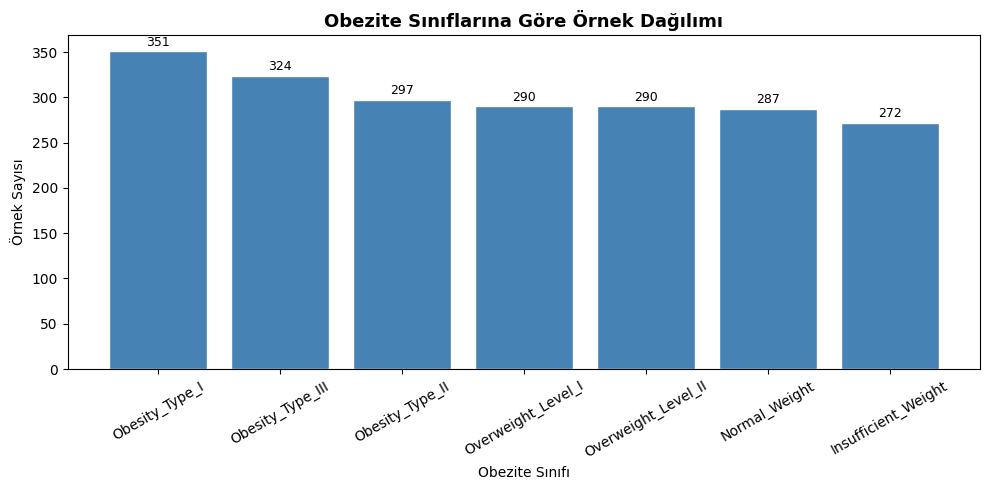

In [ ]:
# Veri Görselleştirme
# Hedef Sınıfının Dağılımı
import matplotlib.pyplot as plt

counts = df['NObeyesdad'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor='white')
ax.set_title("Obezite Sınıflarına Göre Örnek Dağılımı", fontsize=13, fontweight='bold')
ax.set_xlabel("Obezite Sınıfı")
ax.set_ylabel("Örnek Sayısı")
ax.tick_params(axis='x', rotation=30)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3, str(val),
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Veri Önişleme
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols) # kategorik olanlar (sayısal hariç olanlar)

# Her birini encode et
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,2,0,2.0,0,0.0,1.0,3,3,1
1,0,21.0,1.52,56.0,1,0,3.0,3.0,2,1,3.0,1,3.0,0.0,2,3,1
2,1,23.0,1.80,77.0,1,0,2.0,3.0,2,0,2.0,0,2.0,1.0,1,3,1
3,1,27.0,1.80,87.0,0,0,3.0,3.0,2,0,2.0,0,2.0,0.0,1,4,5
4,1,22.0,1.78,89.8,0,0,2.0,1.0,2,0,2.0,0,0.0,0.0,2,3,6


In [ ]:
# Hedef sınıf belirleme ve test verisi eğitim verisi ayırma

X = df.drop('NObeyesdad', axis=1) # hedef dışındaki tüm öznitelikler (axis = 1 -> sütun)
y = df['NObeyesdad'] # hedef sınıf

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # bölerken y'deki sınıf oranlarını koru (sağlıklı/hasta)
)

print(X_train.shape, X_test.shape) # (1688, 16) (423, 16)

(1688, 16) (423, 16)


In [ ]:
# Veri Ölçeklendirme
from sklearn.preprocessing import StandardScaler

# Standardizasyon (Ortalama = 0 / Standart sapma = 1)

scaler = StandardScaler()

# Train verisi üzerinden parametreleri öğren ve verileri dönüştür
X_train_scaled = scaler.fit_transform(X_train)

# Test verisini sadece dönüştür (eğitim verisinden öğrendiği parametrelerle)
X_test_scaled = scaler.transform(X_test)

# Random Forest Model Eğitimi

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# Test verisi tahmin alma
y_pred = rf_model.predict(X_test_scaled)

# Sonuçları yazdır
print(f"Doğruluk (Accuracy) Skoru: {accuracy_score(y_test, y_pred):.4f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred))

# Karmaşıklık Matrisi (Hataları görmek için)
print("\nKarmaşıklık Matrisi:\n", confusion_matrix(y_test, y_pred))

Doğruluk (Accuracy) Skoru: 0.9527

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        54
           1       0.82      0.97      0.89        58
           2       0.97      0.97      0.97        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       0.94      0.88      0.91        58
           6       0.96      0.95      0.96        58

    accuracy                           0.95       423
   macro avg       0.96      0.95      0.95       423
weighted avg       0.96      0.95      0.95       423


Karmaşıklık Matrisi:
 [[50  4  0  0  0  0  0]
 [ 0 56  0  0  0  2  0]
 [ 0  0 68  0  0  0  2]
 [ 0  0  1 59  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  7  0  0  0 51  0]
 [ 0  1  1  0  0  1 55]]


# Karar Ağacı Model Eğitimi

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(X_test_scaled)

In [ ]:
# Sonuçları yazdır
print(f"Doğruluk (Accuracy) Skoru: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_dt))

# Karmaşıklık Matrisi
print("\nKarmaşıklık Matrisi:\n", confusion_matrix(y_test, y_pred_dt))

Doğruluk (Accuracy) Skoru: 0.9173

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.98      0.87      0.92        54
           1       0.78      0.84      0.81        58
           2       0.94      0.93      0.94        70
           3       0.97      0.97      0.97        60
           4       1.00      0.98      0.99        65
           5       0.84      0.88      0.86        58
           6       0.93      0.93      0.93        58

    accuracy                           0.92       423
   macro avg       0.92      0.92      0.92       423
weighted avg       0.92      0.92      0.92       423


Karmaşıklık Matrisi:
 [[47  7  0  0  0  0  0]
 [ 1 49  0  0  0  8  0]
 [ 0  1 65  1  0  0  3]
 [ 0  0  2 58  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  6  0  0  0 51  1]
 [ 0  0  2  0  0  2 54]]


# K-En Yakın Komşu Model Eğitimi



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3) # k = 3 -> 0.82 | k = 5 -> 0.80

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
# Tahminleri al
y_pred_knn = knn_model.predict(X_test_scaled)

# Sonuçları yazdır
print(f"Doğruluk (Accuracy) Skoru: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_knn))

# Karmaşıklık Matrisi
print("\nKarmaşıklık Matrisi:\n", confusion_matrix(y_test, y_pred_knn))

Doğruluk (Accuracy) Skoru: 0.8203

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.73      0.96      0.83        54
           1       0.70      0.52      0.59        58
           2       0.79      0.90      0.84        70
           3       0.92      0.93      0.93        60
           4       0.98      1.00      0.99        65
           5       0.79      0.64      0.70        58
           6       0.80      0.76      0.78        58

    accuracy                           0.82       423
   macro avg       0.82      0.82      0.81       423
weighted avg       0.82      0.82      0.81       423


Karmaşıklık Matrisi:
 [[52  2  0  0  0  0  0]
 [14 30  4  0  0  5  5]
 [ 0  3 63  2  0  2  0]
 [ 0  0  2 56  0  0  2]
 [ 0  0  0  0 65  0  0]
 [ 2  6  9  0  0 37  4]
 [ 3  2  2  3  1  3 44]]


# Lojistik Regresyon Model Eğitimi

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Tahminleri al
y_pred_lr = lr_model.predict(X_test_scaled)

# Sonuçları yazdır
print(f"Doğruluk (Accuracy) Skoru: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_lr))

# Karmaşıklık Matrisi
print("\nKarmaşıklık Matrisi:\n", confusion_matrix(y_test, y_pred_lr))

Doğruluk (Accuracy) Skoru: 0.8676

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.90      0.98      0.94        54
           1       0.83      0.69      0.75        58
           2       0.87      0.93      0.90        70
           3       0.95      0.98      0.97        60
           4       1.00      0.98      0.99        65
           5       0.70      0.78      0.74        58
           6       0.80      0.71      0.75        58

    accuracy                           0.87       423
   macro avg       0.87      0.86      0.86       423
weighted avg       0.87      0.87      0.87       423


Karmaşıklık Matrisi:
 [[53  1  0  0  0  0  0]
 [ 6 40  0  0  0 11  1]
 [ 0  0 65  2  0  1  2]
 [ 0  0  1 59  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  5  1  0  0 45  7]
 [ 0  2  8  0  0  7 41]]


# Naive Bayes Model Eğitimi

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train_scaled, y_train)

GaussianNB()

In [ ]:
# Tahminleri al
y_pred_nb = nb_model.predict(X_test_scaled)

# Sonuçları yazdır
print(f"Doğruluk (Accuracy) Skoru: {accuracy_score(y_test, y_pred_nb):.4f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_nb))

# Karmaşıklık Matrisi
print("\nKarmaşıklık Matrisi:\n", confusion_matrix(y_test, y_pred_nb))

Doğruluk (Accuracy) Skoru: 0.5981

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.69      0.83      0.76        54
           1       0.67      0.41      0.51        58
           2       0.42      0.51      0.46        70
           3       0.43      0.95      0.59        60
           4       1.00      0.98      0.99        65
           5       0.63      0.29      0.40        58
           6       0.71      0.17      0.28        58

    accuracy                           0.60       423
   macro avg       0.65      0.59      0.57       423
weighted avg       0.65      0.60      0.57       423


Karmaşıklık Matrisi:
 [[45  1  7  0  0  1  0]
 [18 24  7  1  0  6  2]
 [ 0  0 36 30  0  2  2]
 [ 0  1  2 57  0  0  0]
 [ 0  0  1  0 64  0  0]
 [ 2  6 18 15  0 17  0]
 [ 0  4 14 29  0  1 10]]


# YSA (Yapay Sinir Ağları - MLP) Model Eğitimi

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

ysa_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),  # 3 gizli katman
    activation='relu',
    max_iter=500,
    random_state=42
)

ysa_model.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500, random_state=42)

In [ ]:
# Tahminleri al
y_pred_ysa = ysa_model.predict(X_test_scaled)

# Sonuçları yazdır
print(f"Doğruluk (Accuracy) Skoru: {accuracy_score(y_test, y_pred_ysa):.4f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_ysa))

# Karmaşıklık Matrisi
print("\nKarmaşıklık Matrisi:\n", confusion_matrix(y_test, y_pred_ysa))

Doğruluk (Accuracy) Skoru: 0.9362

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        54
           1       0.92      0.84      0.88        58
           2       0.95      0.99      0.97        70
           3       0.98      0.97      0.97        60
           4       1.00      0.98      0.99        65
           5       0.84      0.83      0.83        58
           6       0.87      0.95      0.91        58

    accuracy                           0.94       423
   macro avg       0.94      0.93      0.93       423
weighted avg       0.94      0.94      0.94       423


Karmaşıklık Matrisi:
 [[53  1  0  0  0  0  0]
 [ 1 49  0  0  0  8  0]
 [ 0  0 69  0  0  0  1]
 [ 0  0  2 58  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  3  0  0  0 48  7]
 [ 0  0  2  0  0  1 55]]


# SVM Model Eğitimi

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', random_state=42)

svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [ ]:
# Tahminleri al
y_pred_svm = svm_model.predict(X_test_scaled)

# Sonuçları yazdır
print(f"Doğruluk (Accuracy) Skoru: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nSınıflandırma Raporu:\n", classification_report(y_test, y_pred_svm))

# Karmaşıklık Matrisi
print("\nKarmaşıklık Matrisi:\n", confusion_matrix(y_test, y_pred_svm))

Doğruluk (Accuracy) Skoru: 0.8700

Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.94      0.93      0.93        54
           1       0.65      0.74      0.69        58
           2       0.90      0.93      0.92        70
           3       0.95      0.95      0.95        60
           4       1.00      0.98      0.99        65
           5       0.80      0.74      0.77        58
           6       0.85      0.79      0.82        58

    accuracy                           0.87       423
   macro avg       0.87      0.87      0.87       423
weighted avg       0.87      0.87      0.87       423


Karmaşıklık Matrisi:
 [[50  4  0  0  0  0  0]
 [ 3 43  1  0  0  9  2]
 [ 0  2 65  1  0  0  2]
 [ 0  2  1 57  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0 10  1  0  0 43  4]
 [ 0  5  4  1  0  2 46]]
